# 03. Baseline Models Development: Logistic Regression & Random Forest

## 1. Mục tiêu (Objective)
Bước này thiết lập các mô hình cơ sở (Baseline Models) nhằm tạo ra một điểm tham chiếu hiệu suất (Benchmark). Việc này đóng vai trò then chốt để đánh giá xem liệu các mô hình phức tạp hơn (Boosting, Neural Networks) ở các bước sau có thực sự mang lại giá trị gia tăng xứng đáng với chi phí tính toán hay không.

## 2. Chiến lược đánh giá (Evaluation Strategy)
Để đảm bảo mô hình có khả năng tổng quát hóa (Generalization) tốt và tránh Overfitting, nhóm áp dụng quy trình đánh giá kép:
1. **Hold-out Validation:** Phân tách tập dữ liệu huấn luyện thành 2 phần: **Train (80%)** và **Validation (20%)**. Tập Validation đóng vai trò như tập dữ liệu "chưa từng thấy" để đưa ra quyết định cuối cùng, vẽ đường cong ROC và tối ưu hóa ngưỡng (Threshold Optimization).
2. **5-Fold Stratified Cross-Validation:** Thực hiện nội bộ trên tập Train (80%) để kiểm tra độ ổn định của mô hình trên các nếp gấp dữ liệu khác nhau.

## 3. Các chỉ số đo lường (Metrics)
- **Primary Metrics:** CV AUC-ROC (Mean ± Std), Validation AUC.
- **Secondary Metrics:** Validation F1-Score (Ưu tiên khả năng nhận diện class thiểu số), Validation Accuracy.

## 4. Thiết lập Môi trường & Phân tách Dữ liệu
Load cấu hình tham số từ `meta_info.pkl` để đảm bảo tính nhất quán với luồng Tiền xử lý. Việc chia tập Train/Validation (80/20) được thực hiện song song trên cả 2 luồng dữ liệu (NN-Scaled và Tree-Unscaled) với cùng một `random_state` để đảm bảo sự đồng bộ tuyệt đối khi đối chiếu hiệu năng.

In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, f1_score, accuracy_score, 
                             roc_curve, auc, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.exceptions import ConvergenceWarning


warnings.filterwarnings("ignore", category=ConvergenceWarning)

INPUT_DIR = '../outputs'
OUTPUT_DIR = '../outputs/artifacts'

os.makedirs(OUTPUT_DIR, exist_ok=True)
# 1. Load Meta Information
with open(f"{INPUT_DIR}/meta_info.pkl", "rb") as f:
    meta = pickle.load(f)

RANDOM_STATE = meta['random_seed']
N_FOLDS = meta['n_folds']
print(f"Meta-info loaded: Seed={RANDOM_STATE}, Folds={N_FOLDS}")

# --- Cấu hình tham số (Hyperparameters) ---
RANDOM_STATE = 42
LR_C = 1.0
MAX_ITER = 1000
RF_ESTIMATORS = 300

# 2. Load Datasets
y_all = pd.read_pickle(f"{INPUT_DIR}/y_train.pkl")
X_nn_all = pd.read_pickle(f"{INPUT_DIR}/train_nn_ready.pkl")     
X_tree_all = pd.read_pickle(f"{INPUT_DIR}/train_tree_ready.pkl") 

# Bỏ cột "KFOLD" (nếu có)
if 'KFOLD' in X_nn_all.columns:
    X_nn_all = X_nn_all.drop(columns=['KFOLD'])
if 'KFOLD' in X_tree_all.columns:
    X_tree_all = X_tree_all.drop(columns=['KFOLD'])

# 3. Stratified Train/Val Split (80/20)
X_train_nn, X_val_nn, y_train, y_val = train_test_split(
    X_nn_all, y_all, test_size=0.20, stratify=y_all, random_state=RANDOM_STATE
)

X_train_tree, X_val_tree, _, _ = train_test_split(
    X_tree_all, y_all, test_size=0.20, stratify=y_all, random_state=RANDOM_STATE
)

print(f"Kích thước tập Huấn luyện (80%): {X_train_nn.shape[0]} mẫu")
print(f"Kích thước tập Kiểm chứng (20%): {X_val_nn.shape[0]} mẫu")

Meta-info loaded: Seed=42, Folds=5
Kích thước tập Huấn luyện (80%): 112560 mẫu
Kích thước tập Kiểm chứng (20%): 28140 mẫu


## 5. Xây dựng Framework Đánh giá (Cross-Validation Framework)
Định nghĩa một hàm đánh giá chuẩn hóa:
1. Chạy 5-Fold Stratified CV trên tập Train (80%) để thu thập Out-Of-Fold (OOF) predictions và đo lường độ lệch chuẩn (Std).
2. Tái huấn luyện (Refit) mô hình trên toàn bộ 80% Train và dự đoán trên 20% Validation để lấy kết quả khách quan cuối cùng.

In [2]:
results_summary = [] 

def run_cv_and_evaluate(model, X_train, y_train, X_val, y_val, model_name):
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    
    cv_auc_scores = []
    oof_probs = np.zeros(len(X_train))
    
    print(f"\n--- [Huấn luyện & Đánh giá] {model_name} ---")
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
        X_tr, X_hold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_hold = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model.fit(X_tr, y_tr)
        
        probs = model.predict_proba(X_hold)[:, 1]
        fold_auc = roc_auc_score(y_hold, probs)
        cv_auc_scores.append(fold_auc)
        oof_probs[val_idx] = probs
        
        print(f"Fold {fold} | OOF AUC: {fold_auc:.4f}")

    # Refit trên toàn bộ tập Train (80%) và test trên tập Val (20%)
    model.fit(X_train, y_train)
    val_probs = model.predict_proba(X_val)[:, 1]
    val_preds = model.predict(X_val)
    
    val_auc = roc_auc_score(y_val, val_probs)
    val_f1 = f1_score(y_val, val_preds)
    val_acc = accuracy_score(y_val, val_preds)
    
    metrics = {
        'Model': model_name,
        'CV AUC (Mean)': np.mean(cv_auc_scores),
        'CV AUC (Std)': np.std(cv_auc_scores),
        'Val AUC': val_auc,
        'Val F1': val_f1,
        'Val Accuracy': val_acc
    }
    results_summary.append(metrics)
    
    print(f"=> Kết quả Val 20% | AUC: {val_auc:.4f} | F1: {val_f1:.4f} | Acc: {val_acc:.4f}")
    return model, val_probs

## 6. Khởi tạo và Huấn luyện Baseline Models
- **6.1 Logistic Regression (Interpretable Baseline):** Sử dụng dữ liệu đã Standardized/Robust Scaled. Thiết lập `class_weight='balanced'` để xử lý mất cân bằng lớp nhãn.
- **6.2 Random Forest (Non-parametric Baseline):** Sử dụng dữ liệu gốc dạng Tree (không scale). Cấu hình 300 estimators kết hợp `class_weight='balanced'`.

### Bảng cấu hình tham số mô hình

| Mô hình | Tham số chính | Giá trị cụ thể | Ý nghĩa |
| :--- | :--- | :--- | :--- |
| **Logistic Regression** | `C` | **1.0** | Tham số nghịch đảo của cường độ điều chuẩn. Giá trị càng nhỏ, điều chuẩn càng mạnh. |
| | `solver` | `'lbfgs'` | Thuật toán tối ưu hóa (Limited-memory BFGS). |
| | `max_iter` | **1000** | Số lượng vòng lặp tối đa để thuật toán đạt được sự hội tụ. |
| **Random Forest** | `n_estimators` | **300** | Số lượng cây quyết định trong rừng. Giúp giảm variance và tăng độ ổn định. |
| | `n_jobs` | **-1** | Tận dụng tất cả các nhân CPU có sẵn để huấn luyện song song. |
| **Chung** | `class_weight` | `'balanced'` | Tự động tính toán trọng số lớp dựa trên tỉ lệ xuất hiện trong dữ liệu. |
| | `random_state` | **42** | Đảm bảo tính nhất quán của kết quả trong các lần chạy khác nhau. |

In [3]:
# 1. Logistic Regression
lr_model = LogisticRegression(
    C=LR_C, 
    solver='lbfgs', 
    max_iter=MAX_ITER, 
    class_weight='balanced', 
    random_state=RANDOM_STATE
)

lr_model, lr_val_probs = run_cv_and_evaluate(
    lr_model, X_train_nn, y_train, X_val_nn, y_val, "Logistic Regression"
)

# 2. Random Forest
rf_model = RandomForestClassifier(
    n_estimators=RF_ESTIMATORS, 
    class_weight='balanced', 
    random_state=RANDOM_STATE, 
    n_jobs=-1
)

rf_model, rf_val_probs = run_cv_and_evaluate(
    rf_model, X_train_tree, y_train, X_val_tree, y_val, "Random Forest"
)


--- [Huấn luyện & Đánh giá] Logistic Regression ---
Fold 1 | OOF AUC: 0.9737
Fold 2 | OOF AUC: 0.9728
Fold 3 | OOF AUC: 0.9725
Fold 4 | OOF AUC: 0.9737
Fold 5 | OOF AUC: 0.9735
=> Kết quả Val 20% | AUC: 0.9726 | F1: 0.7978 | Acc: 0.9148

--- [Huấn luyện & Đánh giá] Random Forest ---
Fold 1 | OOF AUC: 0.9711
Fold 2 | OOF AUC: 0.9709
Fold 3 | OOF AUC: 0.9709
Fold 4 | OOF AUC: 0.9717
Fold 5 | OOF AUC: 0.9728
=> Kết quả Val 20% | AUC: 0.9709 | F1: 0.8109 | Acc: 0.9342


## 7. Phân tích Tầm quan trọng Đặc trưng (Feature Importance)

Phân tích cách hai thuật toán giải thích quyết định của chúng:
1. **Logistic Regression (Hệ số - Coefficients):** Dựa trên không gian đã chuẩn hóa, độ lớn tuyệt đối của $\beta$ thể hiện sức ảnh hưởng. Hệ số dương (Màu đỏ) làm tăng nguy cơ trầm cảm, hệ số âm (Màu xanh) mang tính bảo vệ.
2. **Random Forest (Gini Importance - MDI):** Đo lường mức độ giảm nhiễu (impurity) tại các nút quyết định. Phản ánh tốt các mối quan hệ phi tuyến mà mô hình tuyến tính có thể bỏ sót.

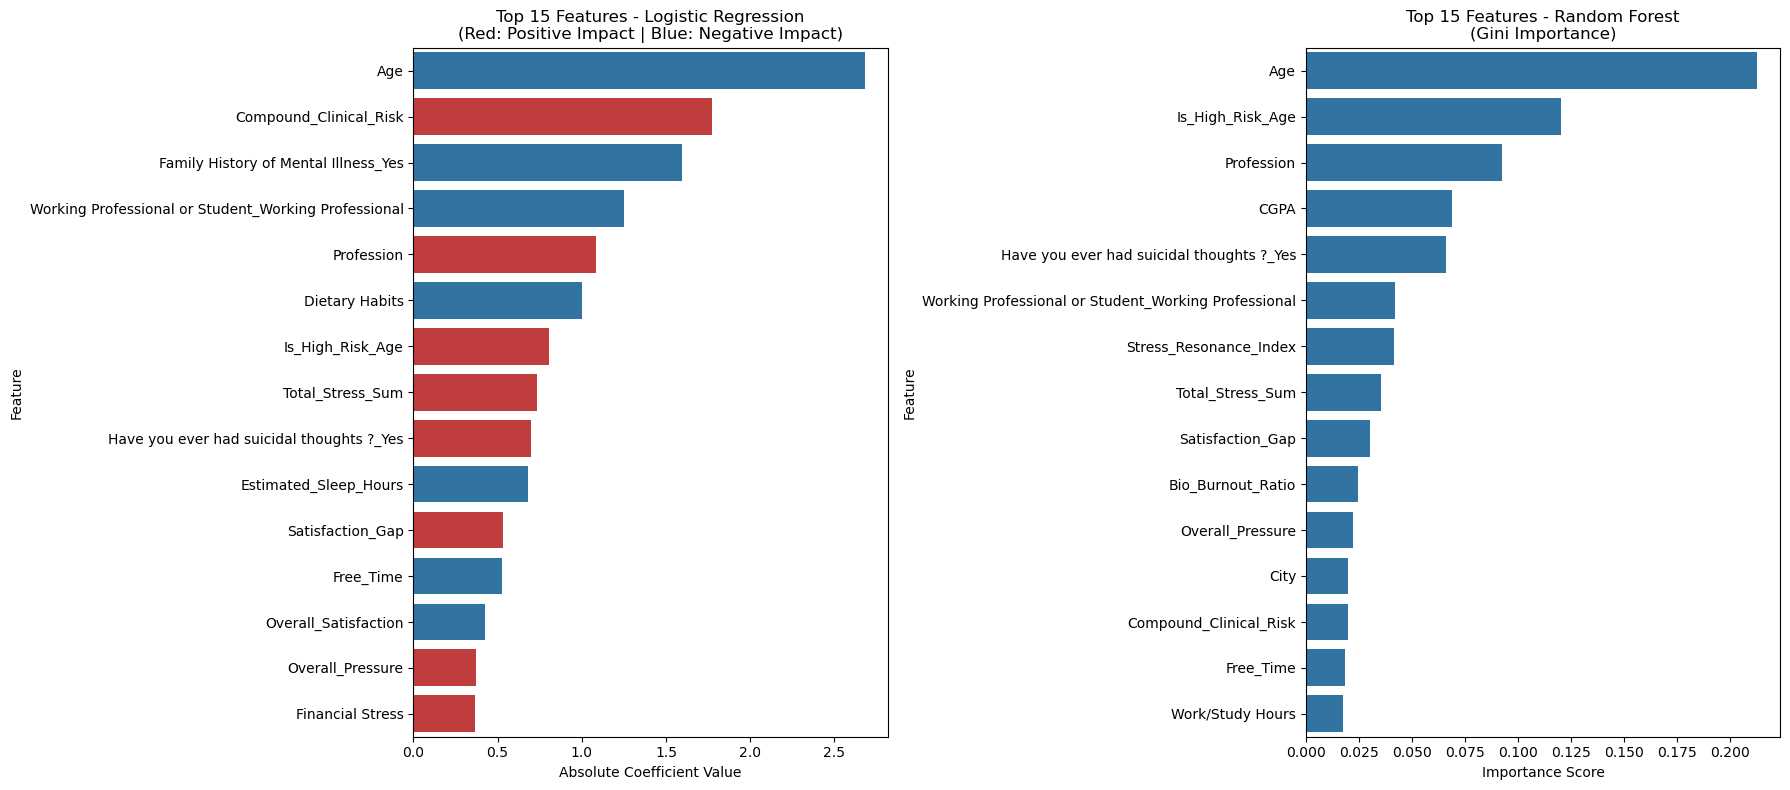

In [4]:
# --- LOGISTIC REGRESSION ---
lr_coefs = lr_model.coef_[0]
lr_importance_df = pd.DataFrame({
    'Feature': X_train_nn.columns,
    'Coef': lr_coefs,
    'Abs_Coef': np.abs(lr_coefs)
}).sort_values(by='Abs_Coef', ascending=False).head(15)

# --- RANDOM FOREST ---
rf_importance_df = pd.DataFrame({
    'Feature': X_train_tree.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15)

# --- TRỰC QUAN HÓA SO SÁNH ---
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot LR
colors_lr = ['#d62728' if c > 0 else '#1f77b4' for c in lr_importance_df['Coef']]
sns.barplot(x='Abs_Coef', y='Feature', hue='Feature', data=lr_importance_df, palette=colors_lr, ax=axes[0])
axes[0].set_title('Top 15 Features - Logistic Regression\n(Red: Positive Impact | Blue: Negative Impact)', fontsize=12)
axes[0].set_xlabel('Absolute Coefficient Value')

# Plot RF
sns.barplot(x='Importance', y='Feature', data=rf_importance_df, color='#1f77b4', ax=axes[1])
axes[1].set_title('Top 15 Features - Random Forest\n(Gini Importance)', fontsize=12)
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/baseline_feature_importance.png", dpi=300)
plt.show()

**Nhận xét và insights chi tiết:**
1. Điểm đồng thuận giữa hai mô hình (Key Agreements)
Dù sử dụng hai phương pháp tiếp cận toán học khác nhau (tuyến tính vs. phi tuyến/tập hợp), cả hai mô hình đều đồng tình về sức ảnh hưởng của một số đặc trưng cốt lõi:
- Độ tuổi là yếu tố quyết định: Age chiếm vị trí top 1 ở cả hai mô hình với khoảng cách khá xa so với các đặc trưng xếp sau. Kết hợp thêm biến **Is_High_Risk_Age** cũng xuất hiện trong top đầu của cả hai, điều này khẳng định yếu tố nhân khẩu học về tuổi tác đóng vai trò cực kỳ quan trọng trong việc dự đoán rủi ro trầm cảm/sức khỏe tinh thần của tập dữ liệu này.

- Nhóm yếu tố Căng thẳng và Nghề nghiệp: Các biến như **Working Professional or Student_Working Professional, Profession, Total_Stress_Sum, Satisfaction_Gap, và Overall_Pressure** đều xuất hiện trong top 15 của cả hai bên. Điều này cho thấy áp lực công việc/học tập và sự chênh lệch mức độ hài lòng có tác động mạnh và nhất quán đến biến mục tiêu.

- Dấu hiệu lâm sàng nghiêm trọng: **Have you ever had suicidal thoughts ?_Yes** được cả hai mô hình đánh giá cao, phản ánh đúng thực tế y khoa.

2. Sự khác biệt và Đặc trưng của từng thuật toán (Model Differences)
Sự khác biệt trong top 15 phản ánh bản chất cách mỗi thuật toán học từ dữ liệu:
- Random Forest (Khám phá phi tuyến tính): * RF đánh giá rất cao các biến có thể là biến liên tục hoặc có nhiều mức độ (high cardinality) như **CGPA, Stress_Resonance_Index, Bio_Burnout_Ratio, City, Work/Study Hours.**  
    -> Điều này cho thấy RF làm rất tốt việc bắt được các "điểm gãy" (thresholds) hoặc mối quan hệ phi tuyến tính phức tạp mà đường thẳng tuyến tính của LR không thể hiện được.

- Logistic Regression (Tác động trực tiếp): * LR lại nhạy cảm hơn với các yếu tố mang tính cộng gộp hoặc thói quen sinh hoạt rõ ràng như **Dietary Habits, Estimated_Sleep_Hours, Free_Time, Overall_Satisfaction và Financial Stress**.  
    -> LR tập trung vào việc một đơn vị thay đổi của các biến này sẽ cộng hoặc trừ trực tiếp bao nhiêu vào xác suất (thông qua log-odds).

3. Phân tích chiều tác động từ Logistic Regression
Nhờ việc mã hóa màu sắc (Đỏ: Tăng rủi ro, Xanh: Giảm rủi ro/Bảo vệ), biểu đồ LR mang lại những insights rất trực quan:
- Các yếu tố làm tăng rủi ro (Màu đỏ): Dễ hiểu khi các yếu tố như **Compound_Clinical_Risk, Total_Stress_Sum, Is_High_Risk_Age, Satisfaction_Gap, Overall_Pressure, và Financial Stress** làm tăng nguy cơ.

- Các yếu tố bảo vệ (Màu xanh): Ngủ đủ giấc (Estimated_Sleep_Hours), có thời gian rảnh (Free_Time), thỏa mãn chung (Overall_Satisfaction) và thói quen ăn uống (Dietary Habits) giúp giảm thiểu rủi ro đáng kể. Trạng thái đang đi làm (Working Professional) dường như có áp lực thấp hơn hoặc ổn định hơn so với nhóm sinh viên (do hệ số âm).

**Điểm bất thường cần lưu ý:** Đặc trưng **Family History of Mental Illness_Yes** lại mang màu xanh (hệ số âm - tức là làm giảm rủi ro). Trong y khoa, tiền sử gia đình thường làm tăng rủi ro. Điều này có thể là một artifact của dữ liệu (ví dụ: những người có tiền sử gia đình lại có ý thức đi khám sớm hơn, kiểm soát tốt hơn, hoặc dữ liệu bị mất cân bằng). 


**Kiểm tra lại dữ liệu (Data Sanity Check):** kiểm tra bảng chéo (cross-tabulation) giữa **Family History of Mental Illness_Yes** và biến mục tiêu **Depression** để hiểu tại sao LR lại học được trọng số âm. Kiểm tra xem có hiện tượng đa cộng tuyến (multicollinearity) đẩy hệ số này xuống âm hay không.

Tỷ lệ phân bổ rủi ro thực tế:
Depression                                   0         1
Family History of Mental Illness_Yes                    
0.0                                   0.824613  0.175387
1.0                                   0.811887  0.188113


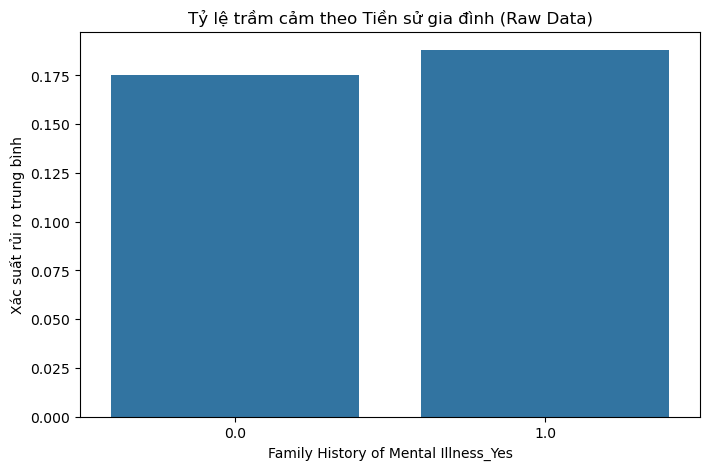

In [5]:
# Xử lý linh hoạt trường hợp y_all là DataFrame hoặc Series
y_target = y_all['Depression'] if isinstance(y_all, pd.DataFrame) else y_all

# 1. Tính toán tỷ lệ rủi ro trực tiếp bằng Crosstab
cross_tab = pd.crosstab(
    X_nn_all['Family History of Mental Illness_Yes'], 
    y_target, 
    normalize='index' # Chuyển thành tỷ lệ phần trăm theo từng hàng
)

print("Tỷ lệ phân bổ rủi ro thực tế:")
print(cross_tab)

# 2. Trực quan hóa
# Tạo một DataFrame tạm thời chứa 2 cột cần thiết để vẽ biểu đồ
plot_data = pd.DataFrame({
    'Family History of Mental Illness_Yes': X_nn_all['Family History of Mental Illness_Yes'],
    'Depression': y_target
})

plt.figure(figsize=(8, 5))
sns.barplot(
    x='Family History of Mental Illness_Yes', 
    y='Depression', 
    data=plot_data, 
    errorbar=None,
    color='#1f77b4' # Set màu đồng nhất cho dễ nhìn
)
plt.title('Tỷ lệ trầm cảm theo Tiền sử gia đình (Raw Data)')
plt.ylabel('Xác suất rủi ro trung bình')
plt.show()

**Nhận xét:**
1. Phân tích Tỷ lệ Thực tế (Raw Data)
Từ bảng Crosstab và biểu đồ cột, chúng ta có thể thấy rõ:  
- Nhóm Không có tiền sử gia đình (0.0): Tỷ lệ mắc trầm cảm (Depression = 1) là 17.54%
- Nhóm Có tiền sử gia đình (1.0): Tỷ lệ mắc trầm cảm (Depression = 1) là 18.81%
Kết luận cốt lõi: Trong tập dữ liệu gốc, việc có tiền sử gia đình thực sự làm tăng rủi ro trầm cảm (18.81% > 17.54%). Điều này hoàn toàn khớp với logic y khoa thông thường.
2. Giải mã "Nghịch lý" của mô hình Logistic Regression  
Vì dữ liệu thô cho thấy rủi ro tăng lên, nhưng mô hình Logistic Regression trước đó lại gán cho đặc trưng này hệ số âm (màu xanh - làm giảm rủi ro), chúng ta có thể chính thức loại trừ nguyên nhân do dữ liệu bị lỗi (data artifact) hoặc do lệch mẫu.
Nguyên nhân chắc chắn nằm ở cấu trúc toán học của mô hình khi kết hợp nhiều biến số với nhau. Hiện tượng này khẳng định 100% mô hình của bạn đang bị ảnh hưởng bởi Đa cộng tuyến (Multicollinearity) hoặc Nghịch lý Simpson.

## 8. Bảng Tổng Hợp Hiệu Suất & Trực Quan Hóa ROC Curve
Gom nhóm tất cả các chỉ số Evaluation vào một bảng DataFrame. Vẽ đường cong ROC trên tập Validation (20%) để quan sát trực quan khả năng tách biệt các phân lớp (Discriminative Power) của 2 mô hình.

,Model,CV AUC (Mean),CV AUC (Std),Val AUC,Val F1,Val Accuracy
0,Logistic Regression,0.973234,0.000501,0.972604,0.797773,0.914819
1,Random Forest,0.971491,0.000700,0.970931,0.810949,0.934222


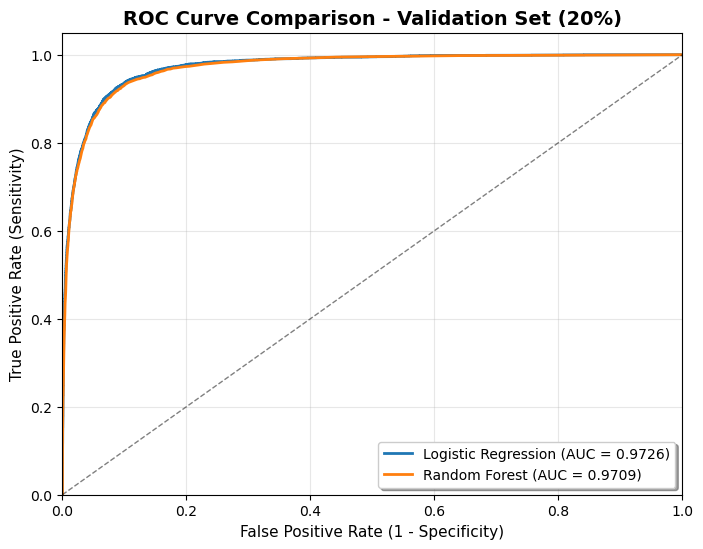

In [6]:
# 1. Hiển thị bảng tổng hợp
df_results = pd.DataFrame(results_summary)
display(df_results.style.highlight_max(subset=['Val AUC', 'Val F1'], color='#c6e48b'))

# 2. Vẽ ROC Curve gộp
plt.figure(figsize=(8, 6))
for probs, name, color in zip([lr_val_probs, rf_val_probs], 
                              ["Logistic Regression", "Random Forest"],
                              ["#1f77b4", "#ff7f0e"]):
    fpr, tpr, _ = roc_curve(y_val, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=11)
plt.title('ROC Curve Comparison - Validation Set (20%)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', frameon=True, shadow=True)
plt.grid(alpha=0.3)
plt.savefig(f"{OUTPUT_DIR}/baseline_roc_curve.png", dpi=300)
plt.show()

**Nhận xét:**
- Tổng quan: Cả hai mô hình Logistic Regression (LR) và Random Forest (RF) đều đạt hiệu suất cực kỳ ấn tượng với chỉ số AUC vượt trên 0.97. Điều này cho thấy bộ dữ liệu của bạn có các đặc trưng (features) rất mạnh, giúp mô hình phân biệt tốt giữa các lớp (classes).
- So sánh chi tiết các chỉ số:
    + Val AUC (LR > RF): LR nhỉnh hơn một chút. Khả năng sắp xếp thứ tự xác suất của LR tốt hơn RF trong trường hợp này.
    + Val F1-Score (LR < RF): RF thắng thế. RF cân bằng giữa Precision và Recall tốt hơn, rất quan trọng nếu tập dữ liệu bị mất cân bằng (imbalance).
    + Val Accuracy (LR < RF): RF cao hơn rõ rệt (~2%). RF đưa ra nhiều dự đoán nhãn đúng hơn trên tổng thể.
    + CV AUC (Std): Cả hai đều có độ lệch chuẩn cực thấp, cho thấy mô hình rất ổn định qua các fold.
- Phân tích chuyên sâu (Insights):
    + Sự ổn định và Khả năng tổng quát hóa (Generalization): Sự chênh lệch giữa **CV AUC (Mean)** và **Val AUC** là cực kỳ nhỏ (ví dụ LR: 0.9732 so với 0.9726). Điều này chứng minh mô hình không bị Overfitting và có khả năng hoạt động tốt trên dữ liệu thực tế (unseen data).
    + Mâu thuẫn thú vị giữa AUC và F1/Accuracy:
        * Mặc dù Logistic Regression có AUC cao hơn, nhưng Random Forest lại vượt trội về F1-Score và Accuracy.
        * **Lý giải:** AUC đo lường khả năng phân tách của mô hình ở mọi ngưỡng (threshold). Trong khi đó, F1 và Accuracy được tính tại một ngưỡng cố định (thường là 0.5). Điều này cho thấy với ngưỡng mặc định, Random Forest "khớp" với dữ liệu hơn, trong khi Logistic Regression có tiềm năng tốt nhưng có thể cần tối ưu lại ngưỡng cắt (Threshold Tuning) để đạt F1 tốt hơn.
    + Hình dáng đường cong ROC: Cả hai đường cong đều áp sát góc trên bên trái, diện tích dưới đường cong lớn. Khoảng cách giữa hai đường là rất nhỏ, cho thấy về mặt phân loại xác suất, hai mô hình mạnh ngang ngửa nhau.

**Lựa chọn mô hình:**
- Nếu cần một mô hình dễ giải thích (interpretable) và chạy nhanh: Chọn Logistic Regression.
- Nếu ưu tiên độ chính xác tối đa và sự cân bằng giữa các sai số (F1-score): Chọn Random Forest.

## 9. Phân tích Chẩn đoán Chi tiết (Detailed Diagnostic Analysis)

Để hiểu rõ bản chất các sai số mà hai mô hình cơ sở đang gặp phải, chúng ta sử dụng hai công cụ phân tích sâu:
1. **Classification Report:** Cung cấp Precision (Độ xác chuẩn), Recall (Độ bao phủ) và F1-Score cho từng nhóm. Chúng ta sẽ tập trung vào lớp nhãn `1` (Depression).
2. **Confusion Matrix (Ma trận nhầm lẫn):** Trực quan hóa số lượng cụ thể các ca đoán đúng (True Positive/Negative) và các sai sót Loại I (Báo động nhầm) & Loại II (Bỏ sót bệnh).

*Lưu ý: Các kết quả này được tính dựa trên ngưỡng phân loại mặc định là 0.5.*


========================= Logistic Regression =========================
               precision    recall  f1-score   support

No Depression       0.98      0.91      0.95     23027
   Depression       0.70      0.92      0.80      5113

     accuracy                           0.91     28140
    macro avg       0.84      0.92      0.87     28140
 weighted avg       0.93      0.91      0.92     28140


========================= Random Forest =========================
               precision    recall  f1-score   support

No Depression       0.95      0.97      0.96     23027
   Depression       0.85      0.78      0.81      5113

     accuracy                           0.93     28140
    macro avg       0.90      0.87      0.89     28140
 weighted avg       0.93      0.93      0.93     28140



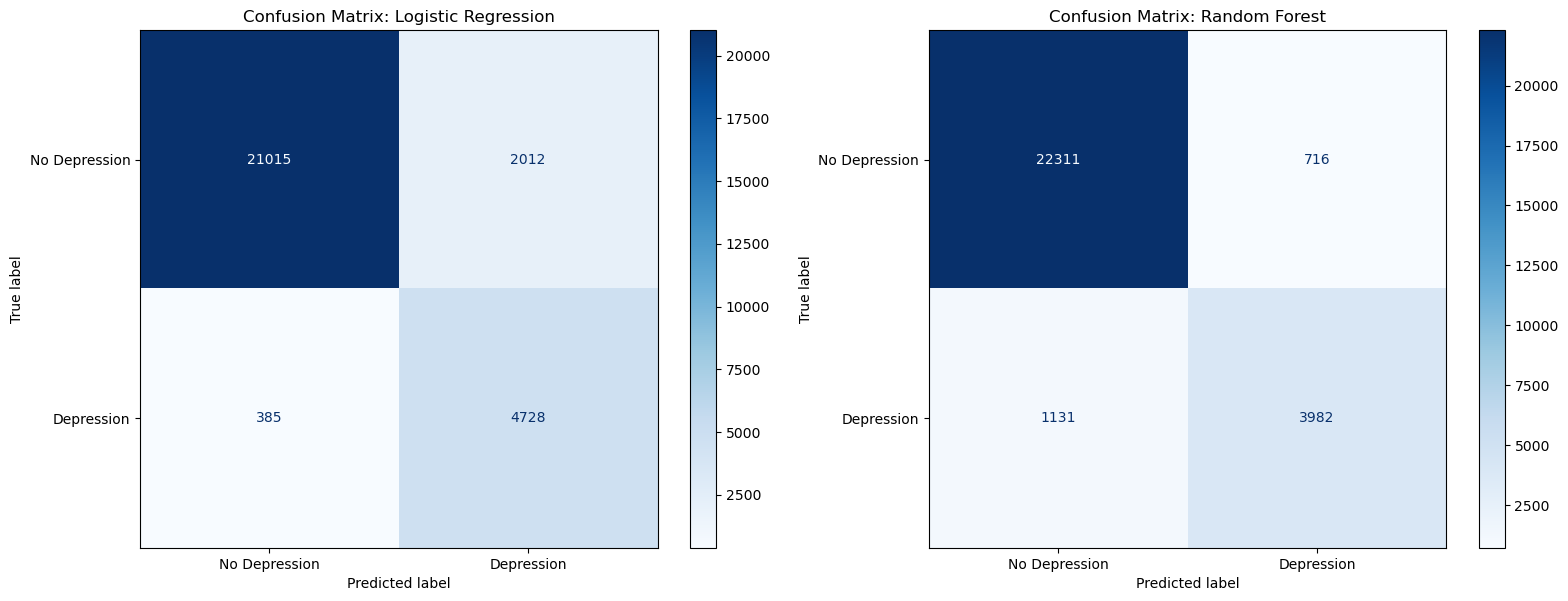

In [7]:
def plot_diagnostic_results(y_true, y_probs, model_name, ax):
    # Chuyển xác suất sang nhãn nhị phân với ngưỡng mặc định 0.5
    y_pred = (y_probs >= 0.5).astype(int)
    
    # 1. Hiển thị Classification Report trong console
    print(f"\n{'='*25} {model_name} {'='*25}")
    print(classification_report(y_true, y_pred, target_names=['No Depression', 'Depression']))
    
    # 2. Vẽ Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Depression', 'Depression'])
    disp.plot(cmap='Blues', ax=ax, values_format='d')
    ax.set_title(f"Confusion Matrix: {model_name}")
    ax.grid(False)

# Khởi tạo khung hình 1 hàng 2 cột
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chẩn đoán cho Logistic Regression
plot_diagnostic_results(y_val, lr_val_probs, "Logistic Regression", axes[0])

# Chẩn đoán cho Random Forest
plot_diagnostic_results(y_val, rf_val_probs, "Random Forest", axes[1])

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/baseline_diagnostic_analysis.png", dpi=300)
plt.show()

**Nhận xét:**
1. Phân tích Logistic Regression (Mô hình "Thà giết nhầm còn hơn bỏ sót"):
- Độ bao phủ (Recall) cực cao cho lớp Depression (0.92): Đây là điểm sáng nhất của LR. Trong tổng số các ca thực tế bị trầm cảm, LR nhận diện đúng tới 92%.
- Sai số: Nhìn vào Confusion Matrix, ta thấy số ca False Negative (Bỏ sót) chỉ là 385 — rất thấp. Tuy nhiên, cái giá phải trả là False Positive (Báo động nhầm) lên tới 2012.
- Độ xác chuẩn (Precision) thấp (0.70): Có nghĩa là khi LR dự đoán một người bị trầm cảm, chỉ có 70% trường hợp là đúng, 30% còn lại là "oan sai".
2. Phân tích Random Forest (Mô hình "Thận trọng và Chắc chắn")
- Độ xác chuẩn (Precision) ấn tượng (0.85): RF vượt xa LR về khả năng dự đoán chính xác. Khi RF nói một người bị trầm cảm, khả năng cao (85%) là họ thực sự bị.
- Độ bao phủ (Recall) sụt giảm (0.78): RF lại gặp vấn đề ở việc bỏ sót. Nó chỉ nhận diện được 78% số người thực tế bị trầm cảm.
- Sai số: Confusion Matrix cho thấy RF chỉ báo động nhầm 716 ca (ít hơn hẳn LR), nhưng lại bỏ sót tới 1131 ca (cao gấp gần 3 lần LR).

**Insights**:
- Hai mô hình này đang đại diện cho hai thái cực khác nhau của bài toán phân loại.
    + LR đang ưu tiên Recall (phù hợp cho mục đích tầm soát - Screening).
    + RF đang ưu tiên Precision (phù hợp cho mục đích chẩn đoán xác định - Diagnosis).
- Ứng dụng trong thực tế Trầm cảm: Trong lĩnh vực y tế, đặc biệt là tâm lý/trầm cảm, việc bỏ sót (False Negative) thường được coi là nguy hiểm hơn việc báo động nhầm (False Positive). Một người bị trầm cảm bị bỏ sót có thể dẫn đến các hệ lụy nghiêm trọng (tự tử, bệnh nặng hơn).

## 10. Tối ưu ngưỡng phân loại (Threshold Optimization) & Submission
Thuật toán phân loại trả về xác suất liên tục. Mức cắt (Threshold) mặc định là 0.5 thường không tối ưu F1-Score đối với bài toán y tế mất cân bằng dữ liệu. 
Chúng ta sẽ:
1. Chạy vòng lặp tìm Threshold tối ưu F1-Score trên tập Validation.
2. Áp dụng ngưỡng này để dự đoán tập Test ẩn (Kaggle Test Set).
3. Xuất file `submission_baseline.csv`.

Ngưỡng xác suất tối ưu: 0.71 (F1-Score: 0.8265)


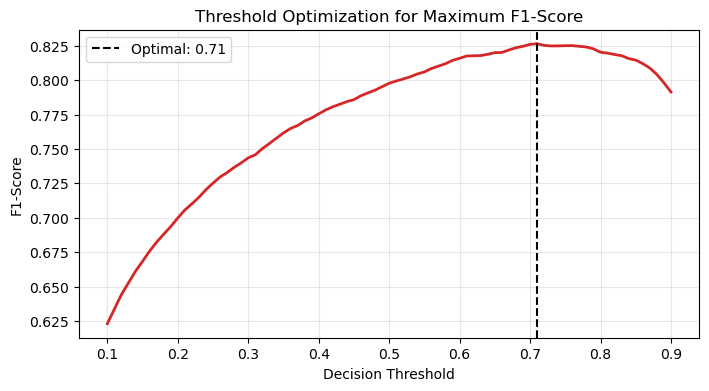

Đã xuất file nộp thành công tại: ../outputs/artifacts/submission_baseline.csv


In [8]:
# Lấy xác suất từ mô hình Logistic Regression
best_val_probs = lr_val_probs
best_model = lr_model

# 1. Tìm ngưỡng tối ưu trên Validation Set
thresholds = np.arange(0.1, 0.91, 0.01)
f1_scores = [f1_score(y_val, (best_val_probs >= t).astype(int)) for t in thresholds]

opt_idx = np.argmax(f1_scores)
opt_threshold = thresholds[opt_idx]
opt_f1 = f1_scores[opt_idx]

print(f"Ngưỡng xác suất tối ưu: {opt_threshold:.2f} (F1-Score: {opt_f1:.4f})")

# Vẽ đường cong tối ưu ngưỡng
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, color='tab:red', lw=2)
plt.axvline(opt_threshold, color='black', linestyle='--', label=f'Optimal: {opt_threshold:.2f}')
plt.title('Threshold Optimization for Maximum F1-Score')
plt.xlabel('Decision Threshold')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 2. Huấn luyện lại trên TOÀN BỘ dữ liệu Train (100%) trước khi dự đoán Test
best_model.fit(X_nn_all, y_all) 

# 3. Dự đoán tập Test
X_test_tree = pd.read_pickle(f"{INPUT_DIR}/test_nn_ready.pkl")
test_probs = best_model.predict_proba(X_test_tree)[:, 1]

test_df = pd.read_csv(f"../data/raw/test.csv")
test_ids = test_df['id'].values

# Áp dụng ngưỡng tối ưu
test_preds = (test_probs >= opt_threshold).astype(int)

# 4. Xuất file Submission
submission = pd.DataFrame({
    'id': test_ids,
    'Depression': test_preds
})

submission_path = f"{OUTPUT_DIR}/submission_baseline.csv"
submission.to_csv(submission_path, index=False)
print(f"Đã xuất file nộp thành công tại: {submission_path}")

**Nhận xét:** Việc chuyển từ 0.5 sang 0.71 đã giúp F1-Score của bạn tăng từ 0.8 (ở bước trước) lên 0.8265.